- It is the type of ML Where machine learns from labeled data.
- e.g House price prediction (area,bedroom, bathroom,location, **price**
- Target variable (Output)/ Dependent variable ![image.png](attachment:3d6a4805-30e7-4e74-8793-e394a7314191.png)![image.png]

## Type of supervised Learning:

### Regression : 
- If our target is numerical then we use regression.
- For we are predicting the price of car: Prediction : $20000
- Model: LinearRegressor, DecisionTreeRegressor, RandomForestRegressor

### Classification:
- It our target is categorical (yes,No)
- for eg. In brain tumor detection project the output is in yes/no
- Model: LogicRegression, MultinumialClassification, DecisionTreeClassifer, RandomForestClassifier

### Model/Algorithm
- Linear Regression:
![image.png](attachment:2b6af572-9641-42ad-ac37-80770fad1845.png)

- Logistic Regression:


- Decision Tree 
- Random Forest
- SVM (Support Vector Machine)
- KNM (K Nearest Neighbour)
- Naive Bays Classifier

- ![image](attachment:7e8336be-8674-4931-99e2-32cbf121573f.png)

    
- Gradient decent

-  ![image.png](attachment:fcf43f02-8481-44cd-a3f5-657ef0e33030.png).


    



### House Price Predection Model

### Step1: Import libraries

In [15]:
import numpy as np ## mathematical calculation
import pandas as pd ## data frame with visualization 
import matplotlib.pyplot as plt ## visualize
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression ## model
from sklearn.tree import DecisionTreeRegressor ## model
from sklearn.ensemble import RandomForestRegressor ## model
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

## Step 2: Load Dataset

In [2]:
df = pd.read_csv('house_price_dataset.csv')
df.head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [3]:
print(df.shape)

(4600, 18)


### Step 3: Data Cleaning and Feature Engineering

In [4]:
## drop the high-cardinality columns:
## columns like street, statezip , country are almost unique so drop them

df = df.drop(['street','statezip','country'], axis = 1)
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond


In [5]:
### encode city
### Two options: Label encodding or One-Hot-Encoding
# le = LabelEncoder()
# df['city'] = le.fit_transform(df['city'])
# df.tail()

### One hot encoding :
df= pd.get_dummies(df,columns=['city'], drop_first = True)
df.tail()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
4595,2014-07-09 00:00:00,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,...,False,True,False,False,False,False,False,False,False,False
4596,2014-07-09 00:00:00,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
4597,2014-07-09 00:00:00,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
4598,2014-07-10 00:00:00,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,...,False,True,False,False,False,False,False,False,False,False
4599,2014-07-10 00:00:00,220600.000000,3.0,2.50,1490,8102,2.0,0,0,4,...,False,False,False,False,False,False,False,False,False,False


In [6]:
df = df[df['price'] > 0]

In [7]:
## feature engineering
# df.info()
# df['house_age'] = df['yr_built']-df['date']
df['date'] = pd.to_datetime(df['date'],errors = 'coerce')
df['year_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month
df = df.drop('date', axis = 1)

df.head()



,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point,year_sold,month_sold
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,True,False,False,False,False,False,False,False,2014,5
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,False,2014,5
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,False,2014,5
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,False,2014,5
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,False,2014,5


In [8]:
df['house_age'] = df['year_sold']-df['yr_built']

df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point,year_sold,month_sold,house_age
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,False,False,False,False,False,False,False,2014,5,59
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,2014,5,93
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,2014,5,48
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,2014,5,51
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,2014,5,38


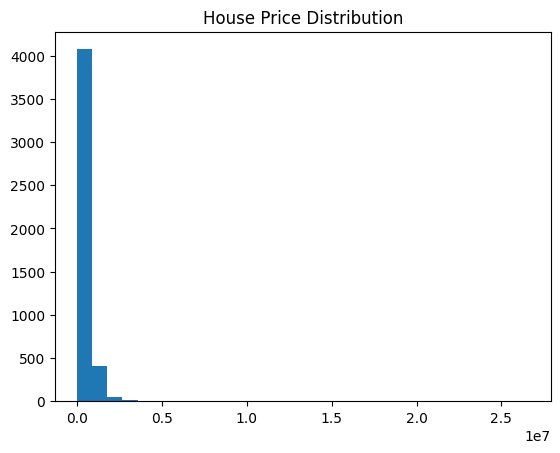

In [9]:
### price distribution

plt.figure()
plt.hist(df['price'], bins = 30)
plt.title("House Price Distribution")
plt.show()


In [10]:
## data is left screwed so we need to log transform
df['price'] = np.log1p(df['price'])

<function matplotlib.pyplot.show(close=None, block=None)>

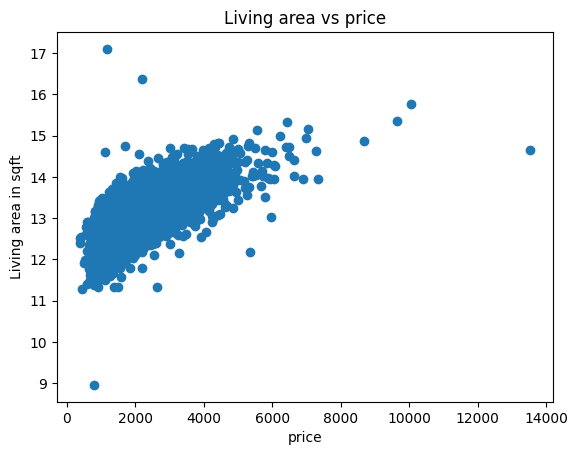

In [11]:
### pairplot for living area vs price

plt.figure()
plt.scatter(df['sqft_living'], df['price'])

plt.title("Living area vs price")
plt.xlabel("price")
plt.ylabel("Living area in sqft")
plt.show

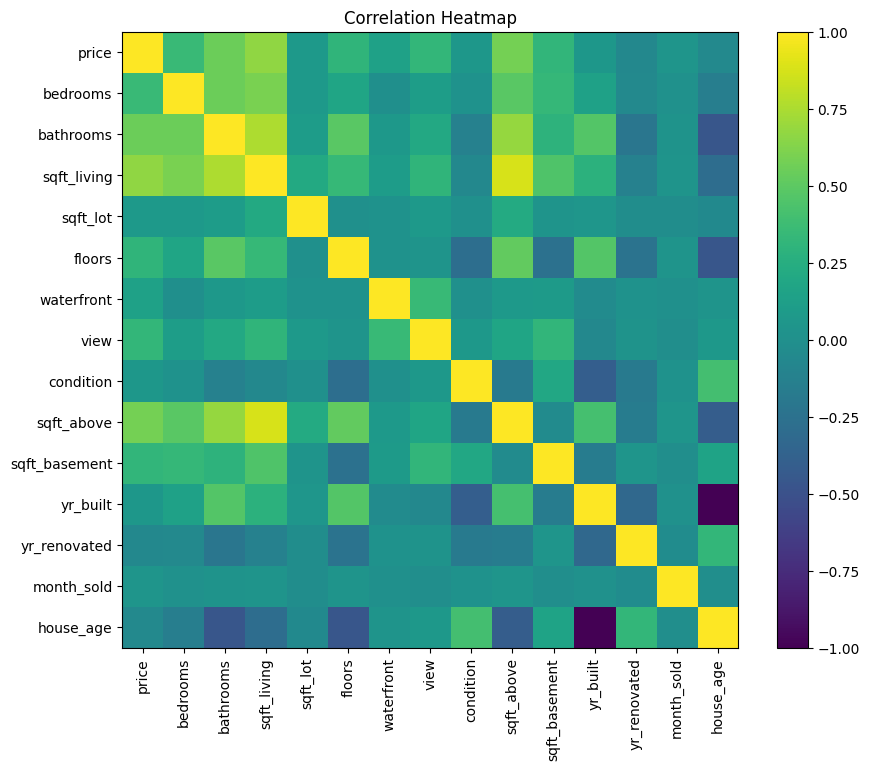

In [12]:
## Corellation heatmap(imp)
df = df.drop('year_sold', axis = 1)


import matplotlib.pyplot as plt

# Select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32'])

plt.figure(figsize=(10, 8))

corr = numeric_df.corr()

# Plot heatmap
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()



### Step 5: Prepare data for modeling

In [25]:
## seperate feature and target

X =df.drop('price', axis = 1)
y = df['price']

print(X.shape)
print(y.shape)

(4551, 57)
(4551,)


### Step 6 : Train test split

In [26]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 7: Model Train

In [28]:
lr = LinearRegression()
model = lr.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("Linear Regression Result:")

print("R2:", r2_score(y_test, y_pred))
print(f"Model is {r2_score(y_test, y_pred)*100}% accurate")

print("MSE", mean_squared_error(y_test, y_pred))

Linear Regression Result:
R2: 0.6622995961588686
Model is 66.22995961588686% accurate
MSE 0.0989205010622302


In [29]:
### dumping the model
import joblib
joblib.dump(model, "house_price_prediction.pk1")

['house_price_prediction.pk1']

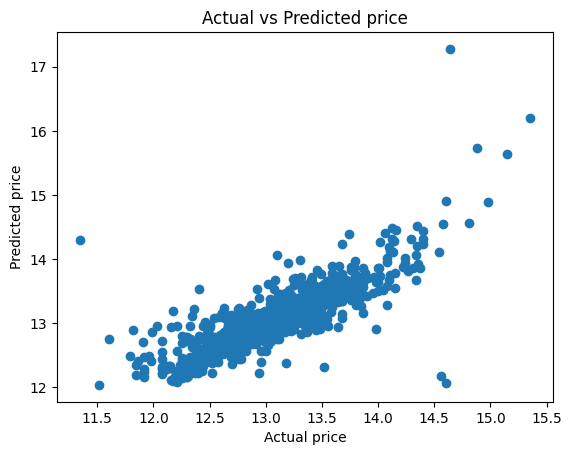

In [31]:
### actual vs pred

plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted price")
plt.show()

In [35]:
## testing
import joblib

joblib.dump(model, "house_price_prediction.pkl")
# load model
lr_test = joblib.load("house_price_prediction.pkl")

sample_dataset = pd.DataFrame([{
    'bedrooms': 4,
    'bathrooms': 2.5,
    'sqft_living': 2000,
    'sqft_lot': 8000,
    'floors': 2.0,
    'waterfront': 0,
    'view': 1,
    'condition': 4,
    'sqft_above': 1800,
    'sqft_basement': 200,
    'yr_built': 1995,
    'yr_renovated': 0,

    # One-hot encoded cities (set ONE city = 1, rest = 0)
    'city_Auburn': 0,
    'city_Beaux Arts Village': 0,
    'city_Bellevue': 0,
    'city_Black Diamond': 0,
    'city_Bothell': 0,
    'city_Burien': 0,
    'city_Carnation': 0,
    'city_Clyde Hill': 0,
    'city_Covington': 0,
    'city_Des Moines': 0,
    'city_Duvall': 0,
    'city_Enumclaw': 0,
    'city_Fall City': 0,
    'city_Federal Way': 0,
    'city_Inglewood-Finn Hill': 0,
    'city_Issaquah': 0,
    'city_Kenmore': 0,
    'city_Kent': 0,
    'city_Kirkland': 0,
    'city_Lake Forest Park': 0,
    'city_Maple Valley': 0,
    'city_Medina': 0,
    'city_Mercer Island': 0,
    'city_Milton': 0,
    'city_Newcastle': 0,
    'city_Normandy Park': 0,
    'city_North Bend': 0,
    'city_Pacific': 0,
    'city_Preston': 0,
    'city_Ravensdale': 0,
    'city_Redmond': 0,
    'city_Renton': 0,
    'city_Sammamish': 0,
    'city_SeaTac': 0,
    'city_Seattle': 1,   # <-- selected city
    'city_Shoreline': 0,
    'city_Skykomish': 0,
    'city_Snoqualmie': 0,
    'city_Snoqualmie Pass': 0,
    'city_Tukwila': 0,
    'city_Vashon': 0,
    'city_Woodinville': 0,
    'city_Yarrow Point': 0,

    'year_sold': 2022,
    'month_sold': 6,
    'house_age': 27
}])

# prediction
prediction = lr_test.predict(sample_dataset)
print(prediction)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- year_sold
